# PBMC 1K ATAC — Pre-Processing Analysis

This notebook is a companion to the [PBMC 1K ATAC tutorial](../PBMC_1K_ATAC.md). It assumes you have already run the `cellranger-snakemake` pipeline and have a processed output directory at `1K_PBMC_ATAC_PROCESSED/`.

**What this notebook covers:**
1. Loading the pipeline output
2. Inspecting the AnnData object and traceability metadata
3. ATAC quality control (fragment counts, duplication rate, mitochondrial fraction)
4. Fragment size distribution
5. Doublet score inspection

## Setup

Set paths to your pipeline output files.

In [19]:
import scanpy as sc
import snapatac2 as snap

# Update these paths to match your output directory
H5AD_PATH = "../PBMC_1K_ATAC/1K_PBMC_ATAC_PROCESSED/08_FINAL/1_atac.h5ad"
SNAP_H5AD_PATH = "../PBMC_1K_ATAC/1K_PBMC_ATAC_PROCESSED/03_ANNDATA/1_L001_snap.h5ad"
CAPTURE_H5AD_PATH = "../PBMC_1K_ATAC/1K_PBMC_ATAC_PROCESSED/03_ANNDATA/1_L001.h5ad"

## Load the data

In [21]:
# SnapATAC2-native object — used for fragment-based plots (frag_size_distr, tsse)
adata_snap = snap.read(SNAP_H5AD_PATH)

# Final enriched object — used for metadata inspection and doublet scores
adata = sc.read_h5ad(H5AD_PATH)

print(adata_snap)
print(adata)

AnnData object with n_obs x n_vars = 1016 x 0 backed at '../PBMC_1K_ATAC/1K_PBMC_ATAC_PROCESSED/03_ANNDATA/1_L001_snap.h5ad'
    obs: 'n_fragment', 'frac_dup', 'frac_mito'
    uns: 'reference_sequences', 'frag_size_distr'
    obsm: 'fragment_paired'
AnnData object with n_obs × n_vars = 1016 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'batch_id', 'capture_id', 'cell_id', 'barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'doublet_scrublet_scrublet_score', 'doublet_scrublet_scrublet_predicted_doublet'
    var: 'gene_ids', 'feature_types', 'derivation', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'


## Per-capture AnnData

The rule `create_atac_anndata` writes two files per capture to `03_ANNDATA/`:

- `1_L001.h5ad` — scanpy AnnData: cells × peaks matrix, SnapATAC2 QC metrics, and traceability metadata
- `1_L001_snap.h5ad` — SnapATAC2-native format: same cells, but stores raw fragment data needed for fragment-level plots

Here we inspect the scanpy per-capture object to confirm the structure before batch aggregation.

In [28]:
adata_capture = sc.read_h5ad(CAPTURE_H5AD_PATH)

print(adata_capture)
print(f"\nObs columns: {list(adata_capture.obs.columns)}")
print()
print(adata_capture.obs[["batch_id", "capture_id", "cell_id", "n_fragment", "frac_dup", "frac_mito"]].head())

AnnData object with n_obs × n_vars = 1016 × 0
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'batch_id', 'capture_id', 'cell_id', 'barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts'
    var: 'gene_ids', 'feature_types', 'derivation', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

Obs columns: ['n_fragment', 'frac_dup', 'frac_mito', 'batch_id', 'capture_id', 'cell_id', 'barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts']

                          batch_id capture_id                    cell_id  \
cell_id                                                                    
1_L001_AAACGAATCGCATAAC-1        1       L001  1_L001_AAACGAATCGCATAAC-1   
1_L001_AAACGAATCTGTGTGA-1        1       L001  1_L001_AAACGAATCTGTGTGA-1   
1_L001_AAACTCGAGAGGAACA-1        1       L001  1_L001_AAACTCGAGAGGAACA-1   
1_L001_AAACTCGAGCCTGTAT

## Verify traceability metadata

Every cell should have `batch_id`, `capture_id`, and a globally unique `cell_id`.

In [22]:
assert "batch_id" in adata.obs.columns
assert "capture_id" in adata.obs.columns
assert "cell_id" in adata.obs.columns
assert adata.obs["cell_id"].is_unique, "cell_id must be unique!"

print(f"Total cells : {adata.n_obs}")
print(f"Total peaks : {adata.n_vars}")
print()
print(adata.obs[["batch_id", "capture_id", "cell_id"]].head())

Total cells : 1016
Total peaks : 0

                          batch_id capture_id                    cell_id
cell_id                                                                 
1_L001_AAACGAATCGCATAAC-1        1       L001  1_L001_AAACGAATCGCATAAC-1
1_L001_AAACGAATCTGTGTGA-1        1       L001  1_L001_AAACGAATCTGTGTGA-1
1_L001_AAACTCGAGAGGAACA-1        1       L001  1_L001_AAACTCGAGAGGAACA-1
1_L001_AAACTCGAGCCTGTAT-1        1       L001  1_L001_AAACTCGAGCCTGTAT-1
1_L001_AAACTCGAGCTGAGGT-1        1       L001  1_L001_AAACTCGAGCTGAGGT-1


## Fragment size distribution

The fragment size distribution reveals the characteristic nucleosomal banding pattern of ATAC-seq: a large sub-nucleosomal peak (~200 bp) followed by declining peaks at mono-, di-, and tri-nucleosomal sizes.

We can immediately view the distribtion like this:

In [23]:
fig = snap.pl.frag_size_distr(adata_snap, show=False)
fig.update_yaxes(type="log")
fig.show()

## TSS enrichment distribution

This metric reveals if there is accessiblility of transcription start sites in the ATAC fragments implying increased accessiblity due to chromatin.

Explore TSS scores against number of unique fragments for each cell like this:

In [24]:
# Calcualte TSS enrichment scores
snap.metrics.tsse(adata_snap, snap.genome.hg38)

# Plot TSS enrichment score distribution
snap.pl.tsse(adata_snap)

## Aggregated metadata

## Doublet scores

Scrublet doublet scores are stored in `doublet_scrublet_scrublet_score` and predictions in `doublet_scrublet_scrublet_predicted_doublet`.

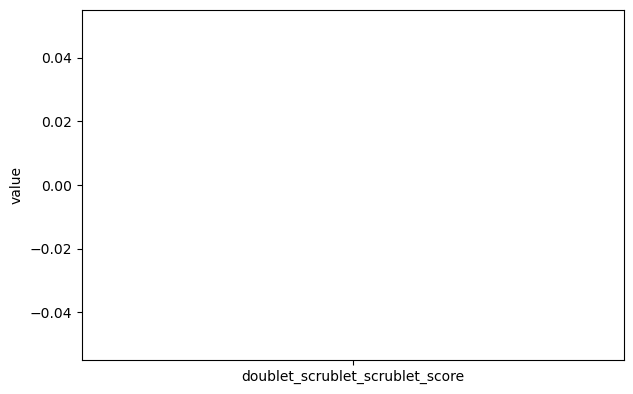

In [25]:
sc.pl.violin(
    adata,
    keys=["doublet_scrublet_scrublet_score"],
    jitter=0.4,
)

In [26]:
predicted = adata.obs["doublet_scrublet_scrublet_predicted_doublet"]
n_doublets = (predicted == 1.0).sum()
n_singlets = (predicted == 0.0).sum()

print(f"Predicted singlets : {n_singlets}")
print(f"Predicted doublets : {n_doublets} ({100 * n_doublets / len(predicted):.1f}%)")

Predicted singlets : 0
Predicted doublets : 0 (0.0%)
